In [1]:
import torch
import time

In [79]:
SIZE = 16384
generator = torch.Generator('mps').manual_seed(0)

A = torch.randn(SIZE, SIZE, generator=generator, dtype=torch.int8, device='mps')
B = torch.randn(SIZE, SIZE, generator=generator, dtype=torch.int8, device='mps')

TypeError: Unsupported type Char for operation normal:Undefined:Undefined

In [78]:
start = time.time()
print(A @ B)
print(time.time() - start)

tensor([[ 197.8750,   50.2500,   -9.0781,  ...,   30.1250,  110.9375,
           90.0000],
        [  42.2500,  131.2500,  105.2500,  ...,  -21.0781,   22.8125,
         -149.6250],
        [-224.2500, -133.3750,  -58.0625,  ...,  -49.5312, -202.2500,
          -87.0000],
        ...,
        [ -26.0156, -284.7500,  -18.7188,  ...,  167.5000,  112.0000,
           54.8438],
        [-242.1250,  316.7500,   45.5625,  ...,  -56.7500,   42.8750,
           40.7500],
        [ 158.1250,  215.6250, -125.6250,  ...,   -9.1016,  126.8125,
          104.2500]], device='mps:0', dtype=torch.float16)
0.7548532485961914


In [61]:
SIZE * SIZE * SIZE * 2 / 1e9 / 0.74

11886.612192172974

In [1]:
import torch
from diffusers import StableDiffusionPipeline, DiffusionPipeline, AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo", 
    torch_dtype=torch.float16, 
    variant="fp16",
    cache_dir='../cache',
    device_map='balanced',
)

/Users/astepanov/repos/mmsteer/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:06<00:00,  1.06it/s]


In [3]:
pipe.text_encoder_2

CLIPTextModelWithProjection(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 1280)
      (position_embedding): Embedding(77, 1280)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-31): 32 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=1280, out_features=1280, bias=True)
            (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
            (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
            (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1280, out_features=5120, bias=True)
            (fc2): Linear(in_features=5120, out_features=1280, bias=True)
          )
          (layer_norm2)

In [4]:
pipe.text_encoder

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), ep

In [12]:
%%time
prompts=[
'Mickey Mouse Shoe Liners 3pk Disney Official Size 4-8UK Adult BNWT',
 # '"""Kids Preferred Disney Baby Melamine Set, Mickey Mouse"""',
 # 'Disney-Traditions-Santa-With-Mickey-And-Minnie-Figurine-0',
 # 'decor furniture mickey mouse bunk bed mickey',
]

images = pipe(
    prompt=prompts,
    num_inference_steps=1,
    guidance_scale=0.0,
    generator=torch.Generator(device='mps').manual_seed(0),
).images

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.71it/s]


CPU times: user 274 ms, sys: 335 ms, total: 609 ms
Wall time: 768 ms


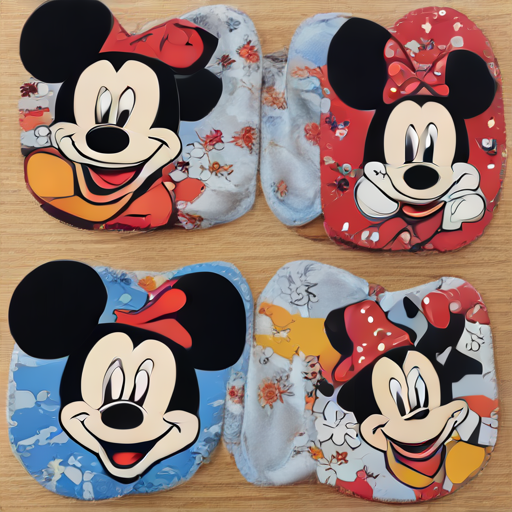

In [9]:
images[0]

In [15]:
from datasets import load_dataset

ds = load_dataset(
    "laion/relaion2B-en-research",
    cache_dir='./cache',
    data_files=[
        f'part-{i:05}-b31ba513-fc6b-4450-9ba4-a1bba183f408-c000.snappy.parquet'
            for i in range(3)
    ]
)

Generating train split: 50688039 examples [00:18, 2765533.38 examples/s]


In [16]:
df = ds['train'].to_pandas()

In [17]:
import re

def generate_concept(dataset: list[str], concept: str) -> tuple[list[str], list[str]]:
    pattern = re.compile(f'(^|[\\s.,-:;]){concept}($|[\\s.,-:;])', flags=re.IGNORECASE)
    pos, neg = [], []
    for text in dataset:
        if text is None:
            continue
        if pattern.search(text) is not None:
            pos.append(text)
        else:
            neg.append(text)
    return pos, neg

In [18]:
pos_sent, neg_sent = generate_concept(df['caption'].values, 'mickey')

In [19]:
len(pos_sent)

33716

In [8]:
pos_sent[:10]

['Mickey Mouse Shoe Liners 3pk Disney Official Size 4-8UK Adult BNWT',
 '"""Kids Preferred Disney Baby Melamine Set, Mickey Mouse"""',
 'Disney-Traditions-Santa-With-Mickey-And-Minnie-Figurine-0',
 'decor furniture mickey mouse bunk bed mickey',
 'Disney Mickey Mouse Umbrella Stroller 3d With Canopy Travel Toddler Baby NEW',
 'Mickey Mouse clubhouse Cake by CupNcakesbyivy',
 'NFL - Carolina Panthers Mickey Mouse Dabbing NFL Football Shirts-T-shirt-Gildan Mens T-Shirt-Royal Blue-S-PopsSpot',
 'Epic Mickey 2 Ps3',
 'kipling-mickey-friends-delia-compact-mickey-friends-convertible-backpack-5',
 'Mickey And Minnie Mouse Plush Disney Toy New Stuffed Set Christmas Store Dolls 1']

In [26]:
with open('concept_prompts/mickey_pos_sentence.txt', 'w') as fout:
    for s in pos_sent:
        print(s, file=fout)

In [27]:
with open('concept_prompts/mickey_neg_sentence.txt', 'w') as fout:
    for s in neg_sent[:35000]:
        print(s, file=fout)